# 02 — Visualising SUPPA results across boundary modes

This notebook tells the story of how the boundary parameter affects
what SUPPA detects, in two steps:

1. **How many events are detected** by generateEvents (IOE counts) —
   all 7 event types, all 6 boundary modes
2. **How many of those are significant** (p < 0.05, |dPSI| ≥ 0.1) —
   focusing on A3, A5, RI for Strict, Variable 1nt and Variable 5nt

The goal is to show that variable mode captures more biologically
relevant events, especially for RI (retained introns).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded!")

Libraries loaded!


In [2]:
# -- Helper functions for styling and exporting tables --
def style_table(df, caption=""):
    """Apply consistent blue-header styling to a DataFrame for display."""
    styled = df.style\
        .set_properties(**{
            "font-size": "12px",
            "font-weight": "bold",
            "border": "1px solid #ddd",
            "padding": "6px 12px",
            "text-align": "center"
        })\
        .set_table_styles([
            {"selector": "th", "props": [
                ("background-color", "#2196F3"),
                ("color", "white"),
                ("font-weight", "bold"),
                ("padding", "6px 12px"),
                ("text-align", "center")
            ]},
            {"selector": "tr:nth-child(even)", "props": [
                ("background-color", "#f2f2f2")
            ]},
        ])\
        .hide(axis="index")
    if caption:
        styled = styled.set_caption(caption)
    return styled

def export_table_png(df, filepath, title=""):
    # Calculate column widths based on longest content in each column
    col_widths = []
    for col in df.columns:
        max_content = max(
            len(str(col)),
            df[col].astype(str).map(len).max()
        )
        col_widths.append(max_content)
    
    # Total figure width proportional to content
    fig_width = max(sum(col_widths) * 0.15, 6)
    fig_height = len(df) * 0.6 + 0.8

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")
    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        loc="center"
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.6)
    for (row, col), cell in table.get_celld().items():
        if row == 0:
            cell.set_facecolor("#2196F3")
            cell.set_text_props(color="white", fontweight="bold")
        elif row % 2 == 0:
            cell.set_facecolor("#f2f2f2")
        else:
            cell.set_facecolor("white")
        cell.set_edgecolor("#dddddd")
    if title:
        ax.set_title(title, fontsize=12, y=0.88)
    plt.tight_layout()
    plt.savefig(filepath, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"Saved to {filepath}")

def highlight_focus(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)
    focus_rows = df["Event"].isin(["A3", "A5", "RI"])
    focus_cols = ["Strict", "Variable 1nt"]
    for col in focus_cols:
        if col in df.columns:
            styles.loc[focus_rows, col] = "color: #2196F3; font-weight: bold"
    return styles

print("Helpers loaded!")

Helpers loaded!


## Table 1 — Events detected by generateEvents across all boundary modes

Raw IOE counts for all 7 event types across 6 boundary modes.
Blue highlighted cells = events and boundaries we focus on (A3, A5, RI × Strict, Variable 1nt).

In [3]:
# All events detected by generateEvents across all boundary modes
data_ioe_all = {
    "Event":        ["SE",   "A3",   "A5",   "MX",  "RI",   "AF",   "AL"],
    "Strict":       [22523, 11164,  9630,  2607,  5316, 33108,  7632],
    "Variable 1nt": [22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 3nt": [22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 5nt": [22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 10nt":[22523, 22932, 19456,  2607, 17337, 33108,  7632],
    "Variable 20nt":[22523, 22932, 19456,  2607, 17337, 33108,  7632],
}

df_ioe_all = pd.DataFrame(data_ioe_all)

display(style_table(df_ioe_all)
    .apply(highlight_focus, axis=None)
    .set_caption("Table 1 — Events detected by generateEvents across all boundary modes"))

export_table_png(
    df_ioe_all,
    "../../figures/plots/table3_ioe_all_boundaries.png",
    title="Table 3 — Events detected by generateEvents across all boundary modes"
)

Event,Strict,Variable 1nt,Variable 3nt,Variable 5nt,Variable 10nt,Variable 20nt
SE,22523,22523,22523,22523,22523,22523
A3,11164,22932,22932,22932,22932,22932
A5,9630,19456,19456,19456,19456,19456
MX,2607,2607,2607,2607,2607,2607
RI,5316,17337,17337,17337,17337,17337
AF,33108,33108,33108,33108,33108,33108
AL,7632,7632,7632,7632,7632,7632


Saved to ../../figures/plots/table3_ioe_all_boundaries.png


## Graph 1 — Strict vs Variable 1nt (zoom-in)

A focused view showing how the number of detected events changes
when switching from strict to variable 1nt boundary mode.
Even a 1nt relaxation nearly doubles detection for A3, A5 and RI.

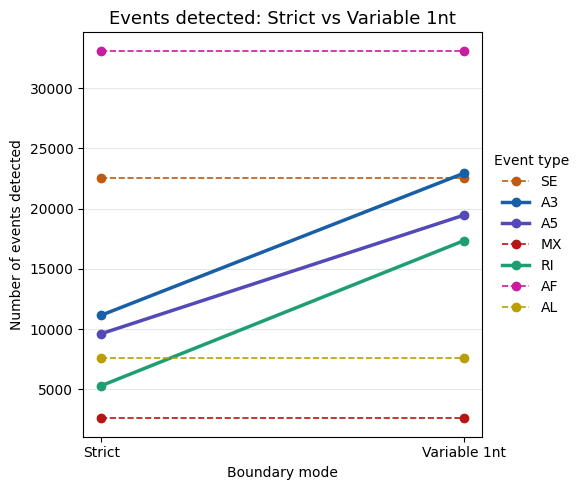

Graph 1 saved!


In [24]:
# color map: event type -> color
event_colors = {
    "A3": "#185FA5",   # blue
    "A5": "#534AB7",   # purple
    "RI": "#1D9E75",   # green
    "SE": "#C05A11",   # amber
    "MX": "#B71414",   # red
    "AF": "#C71D9F",   # pink
    "AL": "#B99E05",   # yellow
}

events_all = ["SE", "A3", "A5", "MX", "RI", "AF", "AL"]

# Graph -  line plot comparing Strict vs Variable 1nt for all events
data_zoom = {
    "Boundary": ["Strict", "Variable 1nt"],
    "SE":  [22523, 22523],
    "A3":  [11164, 22932],
    "A5":  [9630,  19456],
    "MX":  [2607,  2607],
    "RI":  [5316,  17337],
    "AF":  [33108, 33108],
    "AL":  [7632,  7632],
}
df_zoom = pd.DataFrame(data_zoom)

fig, ax = plt.subplots(figsize=(7, 5))
for event in events_all:
    linestyle = "-" if event in ["A3", "A5", "RI"] else "--"
    linewidth = 2.5 if event in ["A3", "A5", "RI"] else 1.2
    ax.plot(df_zoom["Boundary"], df_zoom[event],
            marker="o", label=event, color=event_colors[event],
            linewidth=linewidth, linestyle=linestyle)

ax.set_title("Events detected: Strict vs Variable 1nt", fontsize=13)
ax.set_xlabel("Boundary mode")
ax.set_ylabel("Number of events detected")

#ax.legend(title="Event type")
#ax.grid(axis="y", alpha=0.3)
#plt.tight_layout()

ax.grid(axis="y", alpha=0.3)
ax.legend(title="Event type", loc="center left", 
          bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout(rect=[0, 0, 0.85, 1])


plt.savefig("../../figures/plots/graph1_lineplot_strict_vs_1nt.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph 1 saved!")

## Graph 2 — All boundary modes

Event counts across all 6 boundary modes for all 7 event types.
Events of interest (A3, A5, RI) are shown as solid thicker lines.
The plateau from 1nt onward justifies choosing Variable 1nt as our parameter.

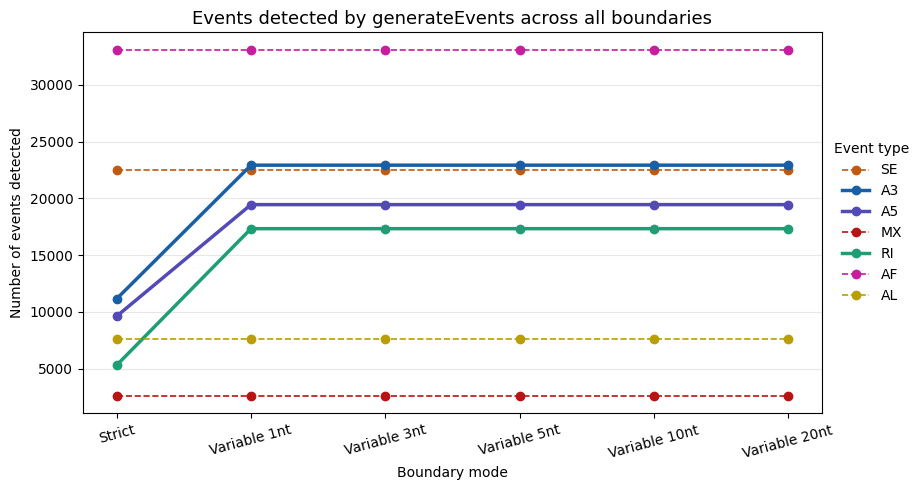

Graph 2 saved!


In [23]:
# Line plot — IOE counts across all boundary modes for all 7 events
boundaries = ["Strict", "Variable 1nt", "Variable 3nt", "Variable 5nt", "Variable 10nt", "Variable 20nt"]

fig, ax = plt.subplots(figsize=(11, 5))
for event in events_all:
    row = df_ioe_all[df_ioe_all["Event"] == event].iloc[0]
    values = [row[b] for b in boundaries]
    linestyle = "-" if event in ["A3", "A5", "RI"] else "--"
    linewidth = 2.5 if event in ["A3", "A5", "RI"] else 1.2
    ax.plot(boundaries, values, marker="o", label=event,
            color=event_colors[event], linewidth=linewidth, linestyle=linestyle)

ax.set_title("Events detected by generateEvents across all boundaries", fontsize=13)
ax.set_xlabel("Boundary mode")
ax.set_ylabel("Number of events detected")

# ax.legend(title="Event type")
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
# plt.tight_layout()

ax.legend(title="Event type", loc="center left", 
          bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout(rect=[0, 0, 0.85, 1])

plt.savefig("../../figures/plots/graph2_lineplot_ioe_counts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graph 2 saved!")

## Graph 3 — Significant events: Strict vs Variable 1nt vs Variable 5nt

Comparing the number of statistically significant events (p < 0.05, |dPSI| ≥ 0.1)
for the three runs of interest, across both comparisons (CT8 vs CT20 and CT20 vs PerKO).
Percentages above Variable bars show the increase relative to Strict.

In [6]:
# Significant events CT8 vs CT20 (p < 0.05, |dPSI| >= 0.1)
data_ct8 = {
    "Event": ["A3", "A5", "RI"],
    "Strict":       [36, 35, 11],
    "Variable 1nt": [73, 63, 62],
    "Variable 5nt": [75, 60, 61],
}

# Significant events CT20 vs PerKO (p < 0.05, |dPSI| >= 0.1)
data_perko = {
    "Event": ["A3", "A5", "RI"],
    "Strict":       [45, 47, 13],
    "Variable 1nt": [73, 76, 64],
    "Variable 5nt": [74, 72, 65],
}

df_ct8 = pd.DataFrame(data_ct8)
df_perko = pd.DataFrame(data_perko)

print("CT8 vs CT20:")
display(df_ct8)
print("CT20 vs PerKO:")
display(df_perko)

CT8 vs CT20:


,Event,Strict,Variable 1nt,Variable 5nt
0,A3,36,73,75
1,A5,35,63,60
2,RI,11,62,61


CT20 vs PerKO:


,Event,Strict,Variable 1nt,Variable 5nt
0,A3,45,73,74
1,A5,47,76,72
2,RI,13,64,65


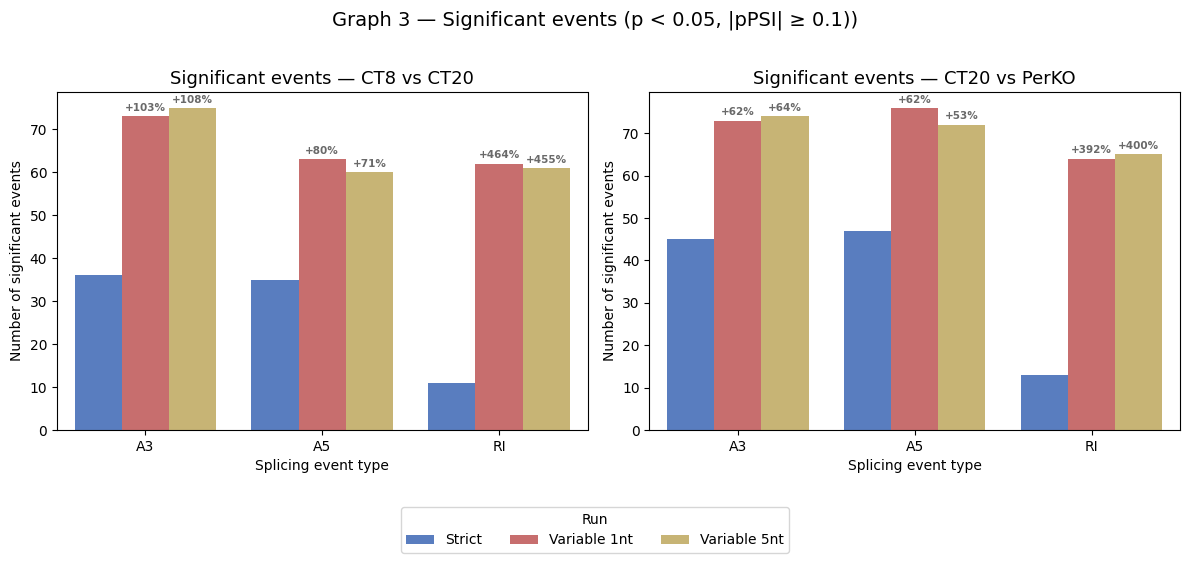

Plot saved to figures/plots/!


In [7]:
def add_pct_labels(ax, df):
    bars = ax.patches
    events = df["Event"].tolist()
    n_events = len(events)
    
    for i, event in enumerate(events):
        strict_val = df[df["Event"] == event]["Strict"].values[0]
        
        # Variable 1nt bars are at index n_events + i
        bar_1nt = bars[n_events + i]
        pct_1nt = ((df[df["Event"] == event]["Variable 1nt"].values[0] - strict_val) / strict_val) * 100
        ax.text(bar_1nt.get_x() + bar_1nt.get_width() / 2,
                bar_1nt.get_height() + 0.8,
                f"+{pct_1nt:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
                color="dimgray", fontweight="bold")
        
        # Variable 5nt bars are at index 2*n_events + i
        bar_5nt = bars[2 * n_events + i]
        pct_5nt = ((df[df["Event"] == event]["Variable 5nt"].values[0] - strict_val) / strict_val) * 100
        ax.text(bar_5nt.get_x() + bar_5nt.get_width() / 2,
                bar_5nt.get_height() + 0.8,
                f"+{pct_5nt:.0f}%",
                ha="center", va="bottom", fontsize=7.5,
                color="dimgray", fontweight="bold")

# Bar plots for CT8 vs CT20 and CT20 vs PerKO

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Reshape data for seaborn
df_ct8_melted = df_ct8.melt(id_vars="Event", var_name="Run", value_name="Count")
df_perko_melted = df_perko.melt(id_vars="Event", var_name="Run", value_name="Count")

# Colors
# palette = {"Strict": "steelblue", "Variable 1nt": "salmon", "Variable 5nt": "mediumseagreen"}
muted = sns.color_palette("muted")
palette = {"Strict": muted[0], "Variable 1nt": muted[3], "Variable 5nt": muted[8]}

# Plot 1 — CT8 vs CT20
sns.barplot(data=df_ct8_melted, x="Event", y="Count", hue="Run",
            palette=palette, ax=axes[0])
axes[0].set_title("Significant events — CT8 vs CT20", fontsize=13)
axes[0].set_xlabel("Splicing event type")
axes[0].set_ylabel("Number of significant events")

# Plot 2 — CT20 vs PerKO
sns.barplot(data=df_perko_melted, x="Event", y="Count", hue="Run",
            palette=palette, ax=axes[1])
axes[1].set_title("Significant events — CT20 vs PerKO", fontsize=13)
axes[1].set_xlabel("Splicing event type")
axes[1].set_ylabel("Number of significant events")

# Annotate percentage increases above Variable bars
add_pct_labels(axes[0], df_ct8)
add_pct_labels(axes[1], df_perko)

# Remove individual legends and add a combined legend below
axes[0].get_legend().remove()
axes[1].get_legend().remove()

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Run", loc="lower center",
           ncol=3, bbox_to_anchor=(0.5, -0.08))

fig.suptitle("Graph 3 — Significant events (p < 0.05, |pPSI| ≥ 0.1))", fontsize=14, y=1.02)
plt.tight_layout()
plt.subplots_adjust(bottom=0.18)
plt.savefig("../../figures/plots/barplot_strict_vs_variable.png", dpi=150, bbox_inches="tight")
plt.show()

print("Plot saved to figures/plots/!")

In [8]:
# ── CELL 1 — Table: IOE Population Summary (Q1 / Q2 / Q3) ──────────────────
 
import os
 
# Read the population counts produced by compare_event_populations.sh
def count_lines(path):
    """Return number of lines in a file (0 if file missing or empty)."""
    if not os.path.exists(path):
        return 0
    with open(path) as f:
        return sum(1 for _ in f)
 
base = "/Users/gricey/Desktop/Internship/data/ioe_populations" # adjust if you ran the script from a different cwd
 
data_pop = {
    "Event": ["A3", "A5", "RI"],
    "Q1 gained": [2711, 2163, 1618],
    "Q2 new":    [3423, 3097, 4405],
    "Q3 novel":  [1266, 1199, 1041],
    "Q4 gained + novel": [823, 817, 693],
}
 
df_pop = pd.DataFrame(data_pop)
 
display(
    style_table(df_pop)
    .set_caption("Table — IOE population comparison: Strict vs Variable 1nt (gene-level)")
)
 
export_table_png(
    df_pop,
    "../../figures/plots/table_ioe_populations.png",
    title="IOE population comparison: Strict vs Variable 1nt"
)
 

Event,Q1 gained,Q2 new,Q3 novel,Q4 gained + novel
A3,2711,3423,1266,823
A5,2163,3097,1199,817
RI,1618,4405,1041,693


Saved to ../../figures/plots/table_ioe_populations.png


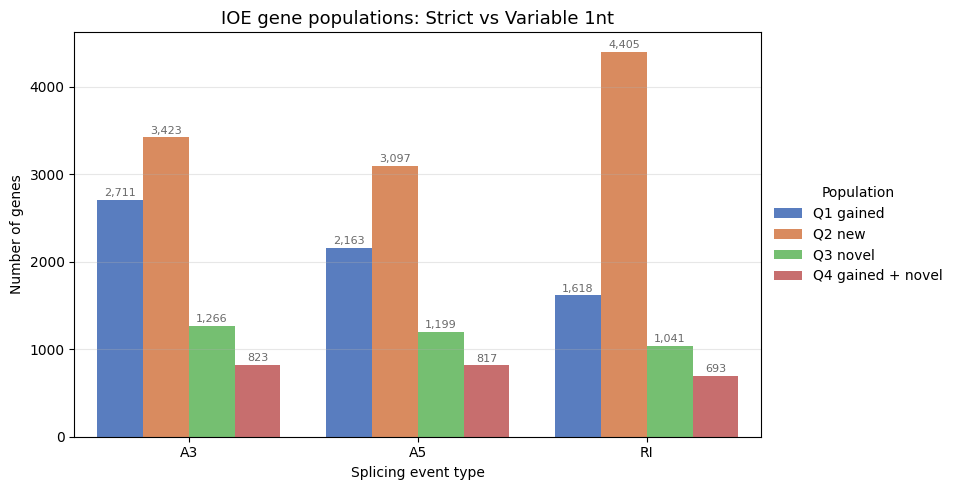

Plot saved!


In [26]:
df_pop_melted = df_pop.rename(columns={
    "Q1 — gained events\n(strict → more, both present)": "Q1 gained",
    "Q2 — new detections\n(0 → events in variable)":    "Q2 new",
    "Q3 — novel transcript events\n(UUID IDs)":         "Q3 novel",
}).melt(id_vars="Event", var_name="Population", value_name="Genes")
 
muted = sns.color_palette("muted", 4)
palette_pop = {
    "Q1 gained": muted[0],
    "Q2 new":    muted[1],
    "Q3 novel":  muted[2],
    "Q4 gained + novel": muted[3],
}
 
fig, ax = plt.subplots(figsize=(11, 5))
 
sns.barplot(
    data=df_pop_melted,
    x="Event", y="Genes", hue="Population",
    palette=palette_pop, ax=ax
)
 
# Annotate bar heights
for bar in ax.patches:
    h = bar.get_height()
    if h > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            h + 20,
            f"{int(h):,}",
            ha="center", va="bottom", fontsize=8, color="dimgray"
        )
 
ax.set_title(
    "IOE gene populations: Strict vs Variable 1nt",
    fontsize=13
)
ax.set_xlabel("Splicing event type")
ax.set_ylabel("Number of genes")
ax.grid(axis="y", alpha=0.3)

ax.legend(title="Population", loc="center left",
          bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout(rect=[0, 0, 0.88, 1])


plt.savefig(
    "../../figures/plots/barplot_ioe_populations.png",
    dpi=150, bbox_inches="tight"
)
plt.show()
print("Plot saved!")